# Chapter 12 - The Scikit-learn library

*This notebook contains all the sample code in Chapter 12.*

## Outline

- [The Scikit-learn library](#Scikit)
    - [Scikit-learn datasets](#datasets)
    - [The Scikit-learn API](#API)
- [Regression examples](#Regression)
    - [Linear regression](#LinReg)
    - [Nearest-neighbor regression](#knnReg)
    - [Linear support vector regression](#svmReg)
- [Classification examples](#Classification)
- [Other supervised-learning approaches](#Other)
    - [Naive Bayes](#NaiveBayes)
    - [Decision trees](#DT)

## The Scikit-learn library <a id="Scikit"></a>

**Scikit-learn** is an open-source library that provides efficient implementations of many machine-learning and data-processing algorithms. Its functionality includes classification, regression, clustering, dimensionality reduction, feature selection, model evaluation, model selection, and data preprocessing.

Only the modules and classes required by a program need to be imported. For example, an entire module can be imported as:

whereas a specific class or function can be imported as:

### Scikit-learn datasets <a id="datasets"></a>

Scikit-learn provides small built-in datasets, larger datasets that can be downloaded when required, and functions for generating synthetic data. Built-in datasets are convenient for learning, testing code, and comparing algorithms.

For example, the Iris dataset can be loaded as follows:

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

A larger dataset can instead be retrieved with a fetcher:

In [2]:
from sklearn.datasets import fetch_lfw_people

people = fetch_lfw_people()

The latter operation requires an Internet connection the first time the dataset is downloaded.

Most loaders and fetchers return a **Bunch** object, which behaves similarly to a dictionary. It typically contains the feature matrix `data`, the target array `target`, a textual description, and, when available, the names of the features and classes:

In [3]:
print(iris.keys())
print(iris.data.shape)
print(iris.feature_names)
print(iris.target_names)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


By convention, the feature matrix is denoted by `X`, whereas the target array is denoted by
`y`:

In [4]:
X = iris.data
y = iris.target

Many loaders also support the compact `return\_X\_y=True` option:

In [5]:
X, y = load_iris(return_X_y=True)

Datasets can also be retrieved from **OpenML**. Specifying a version makes the experiment more reproducible because a dataset name may refer to multiple versions:

In [6]:
from sklearn.datasets import fetch_openml

mice = fetch_openml(name='miceprotein', version=4, as_frame=True)

For supervised learning, the available samples are commonly divided into training and test sets:

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

### The Scikit-learn API <a id="API"></a>

One of the main strengths of Scikit-learn is its consistent API.

A typical supervised-learning workflow consists of the following steps (Step 5 will be discussed and implemented in Chapter 13):

1. Import an estimator class:

2. Instantiate the estimator and set its hyperparameters:

3. Fit the estimator to the training data:

4. Use the fitted model to predict the targets of previously unseen samples:

5. Evaluate the predictions with a suitable metric:

## Regression examples <a id="Regression"></a>

Regression models estimate a continuous target. We first revisit linear regression and then consider a nonlinear, instance-based regressor.

### Linear regression <a id="Lin_Reg"></a>

As previously done, we generate a simple one-dimensional regression dataset:

In [8]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)
x = 10 * rng.random(80)
y = 2 * x - 1 + rng.normal(scale=1.0, size=x.size)

X = x.reshape(-1, 1)

Scikit-learn expects a two-dimensional feature matrix, even when a dataset contains only one feature. Therefore, the one-dimensional array `x` is reshaped into a matrix with one column.

The data are divided into training and test sets, and a linear model is fitted:

In [9]:
from sklearn.linear_model import LinearRegression      # Step 1
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = LinearRegression()          # Step 2
model.fit(X_train, y_train)         # Step 3
y_pred = model.predict(X_test)      # Step 4

The learned slope and intercept are available in `coef_` and `intercept_`:

In [10]:
print('Slope:', model.coef_[0])
print('Intercept:', model.intercept_)

Slope: 2.050072656691804
Intercept: -1.425156634256087


Regression performance should be evaluated with metrics appropriate for continuous targets. Common choices are the **mean absolute error** (MAE) and **root mean squared error** (RMSE):

In [11]:
mae  = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred)**2))

print(f'MAE:  {mae:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE:  0.928
RMSE: 1.169


Finally, the fitted straight line can be plotted over the observations:

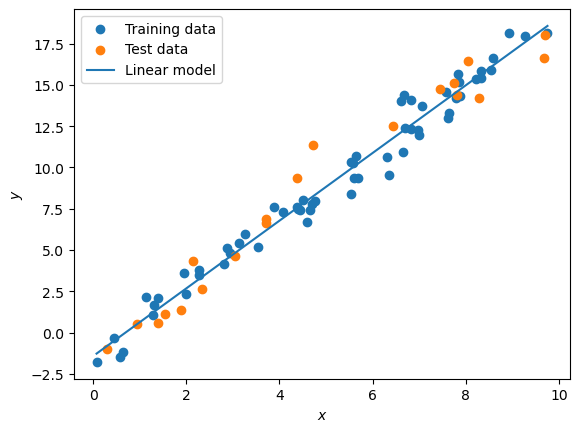

In [12]:
x_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_grid = model.predict(x_grid)

plt.scatter(X_train[:, 0], y_train, label='Training data')
plt.scatter(X_test[:, 0], y_test, label='Test data')
plt.plot(x_grid[:, 0], y_grid, label='Linear model')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show()

### Nearest-neighbor regression <a id="knnReg"></a>

The $k$-nearest-neighbor ($k$-NN) method can also be used for regression. In this case, the prediction is obtained by aggregating the target values of the nearest training samples. The following self-contained example uses a pipeline to standardize the features before computing distances:

In [13]:
from sklearn.neighbors import KNeighborsRegressor   # Step 1

model = KNeighborsRegressor(n_neighbors=5)          # Step 2

model.fit(X_train, y_train)                         # Step 3
y_pred = model.predict(X_test)                      # Step 4

mae  = np.mean(np.abs(y_test - y_pred))             # Step 5
rmse = np.sqrt(np.mean((y_test - y_pred)**2))

print(f'Test MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')

Test MAE: 1.012
RMSE: 1.296


### Linear support vector regression <a id="svmReg"></a>

The support vector machines can also be adapted to regression problems. Scikit-learn implements linear SVR through the `LinearSVR` class. 

Using the same training and test sets introduced in the previous example, the model can be trained as follows:

In [14]:
from sklearn.svm import LinearSVR                   # Step 1

model = LinearSVR(epsilon=0.1, C=10.0, max_iter=10000, random_state=42)

model.fit(X_train, y_train)                         # Step 3
y_pred = model.predict(X_test)                      # Step 4

mae  = np.mean(np.abs(y_test - y_pred))             # Step 5
rmse = np.sqrt(np.mean((y_test - y_pred)**2))

print(f'Test MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')

Test MAE: 0.952
RMSE: 1.170


## Classification examples <a id="Classification"></a>

To make their decision regions directly visible, the following examples use petal length and petal width from the Iris dataset:

In [15]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data[:, 2:4]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

The following utility, employ the function `DecisionBoundaryDisplay` of Scikit-learn, plots the regions predicted by a fitted classifier:

In [16]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

def plot_decision_regions(model, X, y, title):
    disp = DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method='predict',
        plot_method='pcolormesh',
        alpha=0.35,
        xlabel=iris.feature_names[2],
        ylabel=iris.feature_names[3],
    )
    disp.ax_.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    disp.ax_.set_title(title)
    plt.show()

The classifiers can be defined through a common Scikit-learn interface by inserting their objects into a dictionary with keys equal to their names. Specifically, we try a kNN with $k=3$, a Perceptron, a Logistic Regression, an MLP, a linear SVM, and a SVM with RBF kernel:

In [17]:
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

models = {
    '3-NN': KNeighborsClassifier(n_neighbors=3),
    'Perceptron': Perceptron(max_iter=1000, random_state=42),
    'Logistic regression': LogisticRegression(max_iter=1000),
    'MLP': MLPClassifier(hidden_layer_sizes=(20,), max_iter=2000, random_state=42),
    'Linear SVM': SVC(kernel='linear', C=1.0),
    'Kernel SVM': SVC(kernel='rbf', C=1.0)
}

The same training and evaluation code can be applied to every estimator:

3-NN: 93.33%


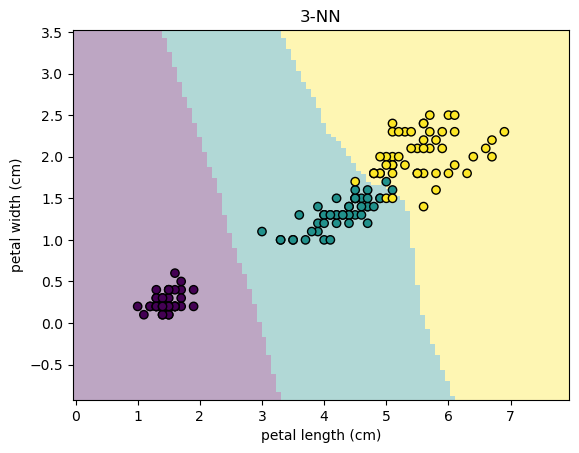

Perceptron: 66.67%


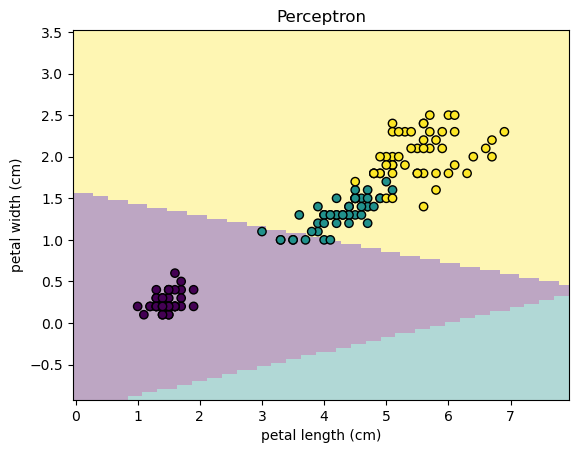

Logistic regression: 93.33%


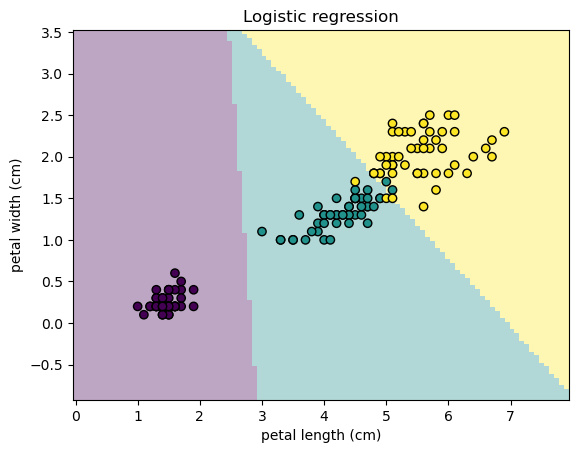

MLP: 93.33%


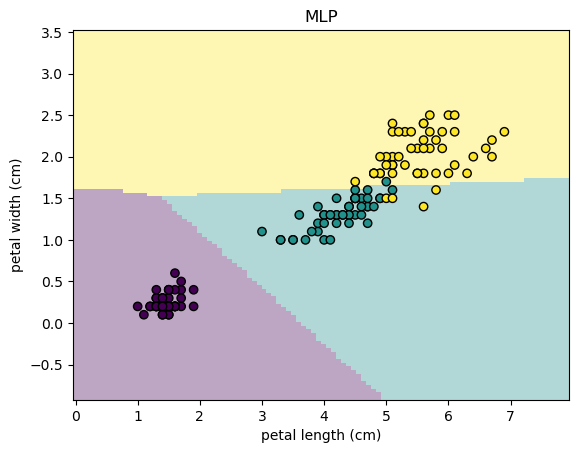

Linear SVM: 93.33%


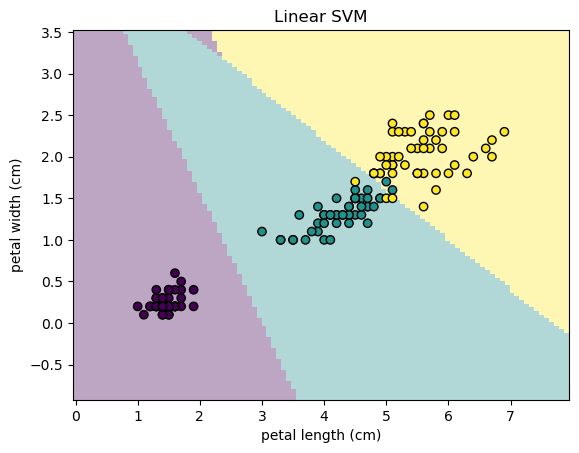

Kernel SVM: 93.33%


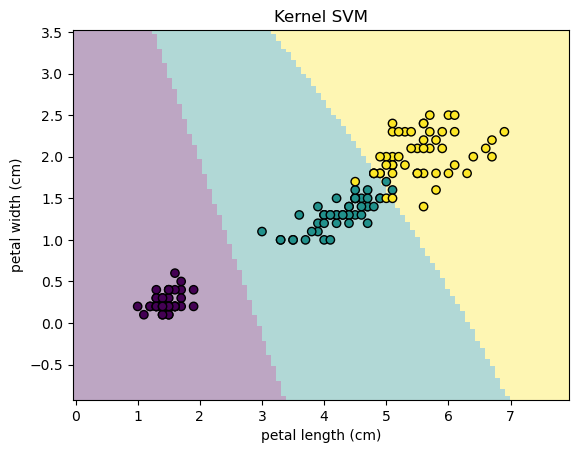

In [18]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = np.mean(y_pred == y_test)

    print(f'{name}: {100 * accuracy:.2f}%')
    plot_decision_regions(model, X, y, name)

## Other supervised-learning approaches <a id="Other"></a>

This section introduces two widely used approaches that were not previously implemented: **Naive Bayes** classifiers and **decision trees**.


### Naive Bayes <a id="NaiveBayes"></a>

**Naive Bayes** denotes a family of probabilistic classifiers based on Bayes' theorem and a simplifying conditional-independence assumption. Despite this strong assumption, these classifiers are computationally efficient and often perform well, particularly in high-dimensional problems such as text classification. The "naive" assumption states that the features are conditionally independent given the class.

The following example evaluates Gaussian Naive Bayes using all four Iris features:

In [19]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print(f'Accuracy: {100 * accuracy:.2f}%')

Accuracy: 92.00%


### Decision trees <a id="DT"></a>

A **decision tree** is a hierarchical, nonparametric model that recursively partitions the feature space. It can be used for both classification and regression. Each internal node tests one feature, each branch represents an outcome of the test, and each leaf stores the final prediction.


#### Classification trees

In a classification tree, the quality of a candidate split is assessed through an *impurity* measure.

The following example trains a shallow classification tree:

Accuracy: 93.33%


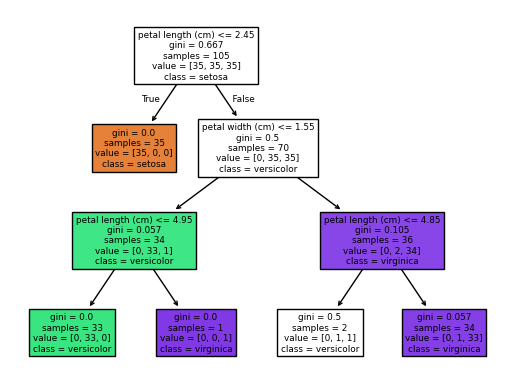

In [20]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

iris = load_iris()
X = iris.data[:, 2:4]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print(f'Accuracy: {100 * accuracy:.2f}%')

plot_tree(
    model,
    feature_names=iris.feature_names[2:4],
    class_names=list(iris.target_names),
    filled=True
)
plt.show()

#### Regression trees

A regression tree partitions the feature space into $J$ terminal regions
$\mathcal{R}_1,\ldots,\mathcal{R}_J$ and predicts a constant value in each region:
$$
\widehat{y}(\mathbf{x}) = \sum_{j=1}^{J} c_j \mathbb{I}\{\mathbf{x}\in\mathcal{R}_j\},
$$
where $\mathbb{I}\{\cdot\}$ is the indicator function.

A regression tree can be implemented as follows:

In [21]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

X, y = make_regression(
    n_samples=300,
    n_features=4,
    noise=20.0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = np.mean(np.abs(y_test - y_pred))
print(f'Test MAE: {mae:.3f}')

Test MAE: 51.767
